# 定理15　認知物理エントロピー交換・保存定理 — 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。
> 定理15は四法印13定理そのものではなく、**定理23（諸行無常）の第一部に必要な「エントロピーの収支」** を与える依存先の定理です。

## 1. 定理15は何を言っているのか

### 設定（原文 §3.7 の記号）

* **物理層** のエントロピー $S_{\mathrm{phys}}(t)$。熱力学的エントロピーで、外部とのやりとりで **増減しうる**。
* **高抽象度の層** $\alpha\succ0$ の **意味エントロピー** $H_\alpha(t)\ge0$（その層での「情報の散らかり度」。認知が秩序立つほど下がる）。
* 各層の **換算重み** $w_\alpha>0$。
* **一般化総エントロピー**

$$
S_{\mathrm{gen}}(t)\;=\;S_{\mathrm{phys}}(t)+\sum_{\alpha\succ0}w_\alpha H_\alpha(t).
$$

### 交換式（仮定 A7）

ほとんど至る所で

$$
\frac{dS_{\mathrm{phys}}}{dt}\;=\;-\sum_{\alpha\succ0}w_\alpha\frac{dH_\alpha}{dt}+\Pi(t),\qquad \Pi(t)\ge0 .
$$

意味エントロピーが **下がる**（秩序化する）と、そのぶん物理エントロピーが **上がる**。これが「交換」です。$\Pi$ は **散逸項**（不可逆性・熱化・余剰生成）です。
原文によれば、A7 の前半（$\Pi$ を $dS_{\mathrm{phys}}/dt+\sum w_\alpha\,dH_\alpha/dt$ と **定義** すること）は内容がなく、実質的な公理は符号条件 $\Pi\ge0$（一般化第二法則）だけです。

### 定理15（原文の主張）

常設仮定 A1〜A5・A6′・A7 のもとで：

* **(I) 交換と一般化第二法則：** $S_{\mathrm{gen}}$ は絶対連続で、$\dfrac{dS_{\mathrm{gen}}}{dt}=\Pi(t)\ge0$（a.e.）、つまり $S_{\mathrm{gen}}(t_2)-S_{\mathrm{gen}}(t_1)=\displaystyle\int_{t_1}^{t_2}\Pi\,ds\ge0$。$S_{\mathrm{gen}}$ は単調非減少。
* **(II) 保存則：** $\Pi=0$（a.e.）$\Longleftrightarrow$ $S_{\mathrm{gen}}$ が定数。とくに理想閉鎖可逆系 $\Pi\equiv0$ では $S_{\mathrm{gen}}(t)=S_{\mathrm{gen}}(0)$。
* **(III) 秩序化量の上界：**
$$
\sum_{\alpha\succ0}w_\alpha\bigl[H_\alpha(t_1)-H_\alpha(t_2)\bigr]=\bigl[S_{\mathrm{phys}}(t_2)-S_{\mathrm{phys}}(t_1)\bigr]-\int_{t_1}^{t_2}\Pi\,ds\;\le\;S_{\mathrm{phys}}(t_2)-S_{\mathrm{phys}}(t_1).
$$
区間内で達成できる認知的秩序化の総量は、同じ区間の物理エントロピー増加量で上から押さえられる、という意味です。

### 「物理層だけでは保存則がない」

物理層だけを見るとき、エントロピーについて成り立つのは第二法則の **不等式** $dS_{\mathrm{phys}}/dt\ge0$（閉じた系の場合）だけで、**等式の保存則はありません**。高抽象度の層まで含めて初めて、交換による等式の保存則 $S_{\mathrm{gen}}=\text{const}$（$\Pi\equiv0$ のとき）が立ちます。

### 可算無限層には条件 A6′(ii) が要る

層が **可算無限個** ある場合、「各層の微分の和」＝「合計の微分」（項別微分）が成り立つとは限りません。原文は、有限部分和の族 $\bigl\{\sum_{\alpha\in\mathcal A'}w_\alpha h_\alpha\bigr\}$（$h_\alpha=dH_\alpha/dt$）が $L^1([0,T])$ で **一様可積分** であること（A6′(ii)）を要求します。
これを落とすと結論が破綻する、というのが §3.7.5 の反例（**高木関数型**）です。このノートの (B) がそれです。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| 層数 | 有限6層（(A)）／可算無限層（(B)） | `K = 6` |
| $w_\alpha$ | 換算重み | `w = 2.0 ** -np.arange(K)` |
| $H_\alpha(t)\ge0$ | 意味エントロピー。$H_k=2+\sin(0.7(k+1)t)$ | `H` |
| $h_\alpha=dH_\alpha/dt$ | その時間微分 | `h`（数値微分） |
| $\Pi(t)\ge0$ | 散逸項 | `Pi`（2通り） |
| $S_{\mathrm{phys}}$ | 物理エントロピー。A7 から積分して作る（$S_{\mathrm{phys}}(0)=5$） | `S_phys` |
| $S_{\mathrm{gen}}$ | 一般化総エントロピー | `S_gen` |

## 2. なぜこれが「定理15の例」と言えるのか

* **(A)** 有限6層なので A6′(ii) は **自明に成り立ちます**（有限和）。$H_k$ は滑らか（A2）。物理エントロピー $S_{\mathrm{phys}}$ は、交換式 (A7) を **満たすよう積分して作って** います。つまり A7 を成り立たせた上で、定理15の結論 (I)(II)(III) が数値でも見えることを確かめる例です。
  散逸 $\Pi$ は2通り：$\Pi\equiv0$（理想閉鎖可逆系）と $\Pi=0.5(1+\sin t)\ge0$。
* **(B)** は仮定 A6′(ii) **だけを破る** 反例です。$H_k=2^{-k}(1+\sin(4^kt))$ は和 $\sum H_k$ は一様収束しますが（A6′(i) は成立）、各項の微分の絶対値が $2^k$ のオーダーで **増え続ける**。これは定理15の反例ではなく、**「仮定A6′(ii) を落とすと何が壊れるか」** の例です。

## 3. (A) 有限6層：交換式を満たす $S_{\mathrm{phys}}$ を作る

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

t = np.linspace(0, 10, 20001); dt = t[1] - t[0]
K = 6
w = 2.0 ** -np.arange(K)                       # 換算重み w_α>0
H = np.array([2 + np.sin(0.7 * (k + 1) * t) for k in range(K)])   # H_α(t) ≥ 0
h = np.gradient(H, dt, axis=1)                 # dH_α/dt
cum = lambda f: np.concatenate([[0], np.cumsum((f[1:] + f[:-1]) / 2) * dt])   # 台形則の積分

def exchange(Pi):
    dS_phys = -(w[:, None] * h).sum(axis=0) + Pi          # (A7)
    S_phys = 5.0 + cum(dS_phys)
    S_gen = S_phys + (w[:, None] * H).sum(axis=0)
    return S_phys, S_gen

cases = {"Π≡0 (理想閉鎖可逆系)": np.zeros_like(t), "Π=0.5(1+sin t)≥0": 0.5 * (1 + np.sin(t))}
res = {k: exchange(P) for k, P in cases.items()}

`exchange` が (A7) $\dot S_{\mathrm{phys}}=-\sum w_\alpha h_\alpha+\Pi$ を積分して $S_{\mathrm{phys}}$ を作り、$S_{\mathrm{gen}}=S_{\mathrm{phys}}+\sum w_\alpha H_\alpha$ を計算します。積分は台形則です。

## 4. (B) 高木型の反例：導関数の総変動

In [2]:
# %% (B) 反例: 導関数の総変動が発散
def total_variation(N, tt):
    F = sum(2.0 ** -k * (1 + np.sin(4.0 ** k * tt)) for k in range(1, N + 1))
    return np.abs(np.diff(F)).sum(), F
tt = np.linspace(0, 1, 400001)
Ns = [1, 2, 3, 4, 5, 6, 7]
TV = [total_variation(N, tt)[0] for N in Ns]
sup_tail = [2.0 ** -N * 2 for N in Ns]         # ΣH_k の一様収束(尾の上界)

部分和 $F_N(t)=\sum_{k=1}^{N}2^{-k}\bigl(1+\sin(4^kt)\bigr)$ を $[0,1]$ で作り、その **総変動**（$|F_N(t_{i+1})-F_N(t_i)|$ の和＝グラフの上下の動きの合計）を数えています。一様収束の尾の上界は $2^{1-N}$ です。

## 5. 図を読む

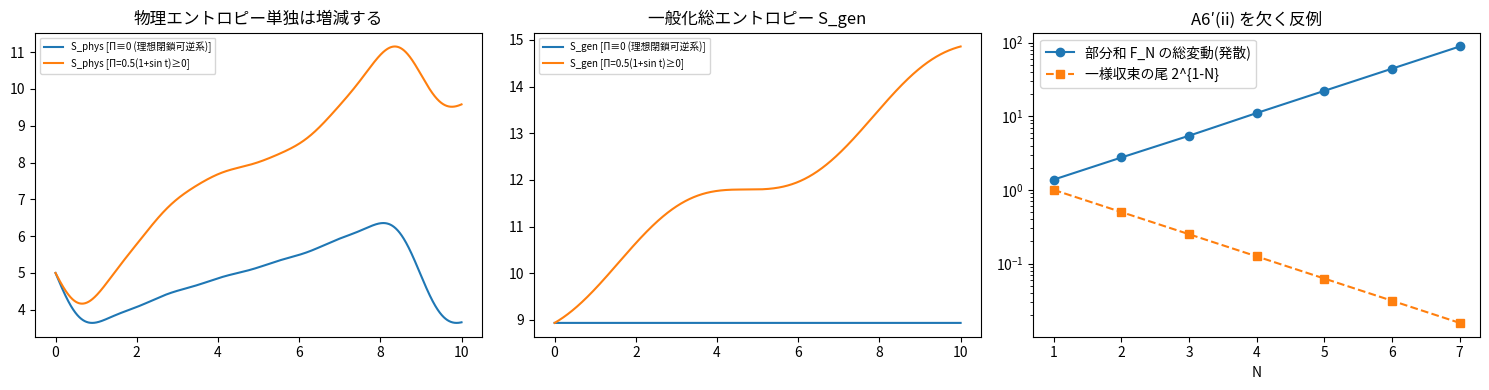

In [3]:
# %% 可視化
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for (k, (Sp, Sg)), P in zip(res.items(), cases.values()):
    ax[0].plot(t, Sp, label=f"S_phys [{k}]"); ax[1].plot(t, Sg, label=f"S_gen [{k}]")
ax[0].set_title("物理エントロピー単独は増減する"); ax[1].set_title("一般化総エントロピー S_gen"); ax[0].legend(fontsize=7); ax[1].legend(fontsize=7)
ax[2].semilogy(Ns, TV, "o-", label="部分和 F_N の総変動(発散)"); ax[2].semilogy(Ns, sup_tail, "s--", label="一様収束の尾 2^{1-N}")
ax[2].set_title("A6′(ii) を欠く反例"); ax[2].legend(); ax[2].set_xlabel("N")
plt.tight_layout(); plt.show()

### 左：物理エントロピー単独 $S_{\mathrm{phys}}$

青（$\Pi\equiv0$）も橙（$\Pi=0.5(1+\sin t)$）も、**増えたり減ったりしています**。
青は $5\to$ 約 $3.6\to$ 約 $6.3\to$ 約 $3.6$ と上下します。$\Pi\equiv0$（散逸ゼロ）でも $S_{\mathrm{phys}}$ は **一定ではありません**。交換式に従って、意味エントロピーの変動のぶんだけ動くからです。
つまり、物理層だけを見ても「保存則」は見えません。

### 中：一般化総エントロピー $S_{\mathrm{gen}}$

* **青（$\Pi\equiv0$）：完全に水平** です（約 $8.94$。数値の変動幅は約 $5\times10^{-7}$）。**左で上下していた $S_{\mathrm{phys}}$ のぶんを、$\sum w_\alpha H_\alpha$ が打ち消している** のが保存則 (II) です。
* **橙（$\Pi\ge0$）：単調に増加。** 約 $8.94$ から約 $14.9$ まで。ところどころ平らに近い部分（$t\approx4$〜$5.5$）は $\Pi=0.5(1+\sin t)$ が $0$ に近い時間帯（$\sin t\approx-1$、$t\approx4.71$）に対応します。増加量はちょうど $\int_0^{10}\Pi\,ds=0.5\,(10+1-\cos10)\approx5.92$ で、$8.94+5.92\approx14.86$ と図の終点に一致します。これが (I) の $S_{\mathrm{gen}}(t_2)-S_{\mathrm{gen}}(t_1)=\int\Pi$ です。

### 右：A6′(ii) を欠く反例（縦軸は対数）

* **青の丸（部分和の総変動）：** $N=1,\dots,7$ で約 $1.4,\ 2.8,\ 5.4,\ 11,\ 22,\ 44,\ 89$。**$N$ が 1 増えるごとにほぼ2倍** で、**発散** していきます。
* **橙の四角（一様収束の尾 $2^{1-N}$）：** 同じ $N$ で **半分ずつ減って** $0$ に近づきます。

つまり、**関数 $\sum H_k$ の値はきれいに収束する（尾が小さくなる）のに、その変わり方（総変動）はいくらでも大きくなる** のが、高木型の病理です。各項の微分の和を取る操作が破綻する（項別微分が保証されない）ので、交換式 A7 の「打ち消し」も意味を失います。

## 6. 数値確認

In [4]:
# %% 数値確認
S0 = res["Π≡0 (理想閉鎖可逆系)"]; S1 = res["Π=0.5(1+sin t)≥0"]
print("Π≡0: S_gen の変動幅 =", np.ptp(S0[1]), " / S_phys の変動幅 =", np.ptp(S0[0]))
print("総変動 TV(F_N):", np.round(TV, 2))
assert np.ptp(S0[1]) < 1e-3 and np.ptp(S0[0]) > 0.1          # 保存(S_gen) vs 物理層単独は保存しない
assert (np.diff(S1[1]) >= -1e-9).all()                       # 一般化第二法則
assert abs((S1[1][-1] - S1[1][0]) - cum(cases["Π=0.5(1+sin t)≥0"])[-1]) < 1e-3   # 積分収支
assert TV[-1] > 10 * TV[2] and np.diff(TV)[-1] > 0            # 総変動が発散(各項 O(2^N) で増える)

Π≡0: S_gen の変動幅 = 4.975344722879527e-07  / S_phys の変動幅 = 2.7124249930031326
総変動 TV(F_N): [ 1.38  2.75  5.43 11.05 22.12 44.25 88.5 ]


* $\Pi\equiv0$：$S_{\mathrm{gen}}$ の変動幅は約 $5\times10^{-7}$（保存）、$S_{\mathrm{phys}}$ の変動幅は約 $2.7$（保存しない）。
* $\Pi\ge0$：$S_{\mathrm{gen}}$ は単調非減少、増加量は $\int\Pi$ に一致（積分収支）。
* 総変動は $N=7$ で約 $88.5$、$N=3$ の約 $5.4$ の 10 倍を超えて増え続けます。

## 7. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **諸行無常（定理23）の第一の柱の土台。** 原文は定理23第一部を「生きている ＝ 散らかり度の生成が止まらない」と説明します。定理15は、その「散らかり度」$S_{\mathrm{gen}}$ が $\Pi\ge0$ の分だけ **増え続ける** ことを保証する部品です。$\int\Pi>0$ なら $S_{\mathrm{gen}}$ が増えるので、完全状態は **二度と同じにならない**（状態だけで決まる量が違う値になるから）、という論法です。
* **秩序化には代償がある。** (III) は「認知側の秩序化の総量は、物理側のエントロピー増加で押さえられる」と言います。学ぶ・整理するといった秩序化も、物理的な帳簿のどこかにコストがある、という読み方ができます。
* **空・高抽象度との関係。** 物理層だけでは保存則がなく、**高抽象度層まで含めて** 初めて保存則が立つ、という点は、抽象度のはしごを上へたどる原文全体の立場（定理19・22・23）に沿っています。
* ただし、この例は「$\Pi$ の正体」や「換算重み $w_\alpha$ の物理的な決まり方」までは扱いません。A7 は原文の **独立した公理**（一般化第二法則）で、ここでは仮定しています。

## 8. Lean との対応

対応ファイル：(A) `Tomabechi/Examples/Theorem15_EntropyExchange.lean`、(B) `Tomabechi/Examples/Theorem15_A6Failure.lean`（一般定理は `Theorem15.lean`・`EntropyBalance.lean` 側）。

| | 内容 | 状態 |
| --- | --- | --- |
| (A) 有限6層 | 交換式の全前提と収支 (I)(III)、$\Pi\equiv0$ で $S_{\mathrm{gen}}$ 保存かつ $S_{\mathrm{phys}}$ は **非保存**、$S_{\mathrm{gen}}$ 単調 | 証明済 |
| (B) A6′(ii) の破れ | 有限部分和の族 $\{\sum_{k\in s}w_kh_k\}$ が $L^1[0,1]$ で **有界でない**（単独層で $\lVert h_N\rVert_{L^1}\ge2^N/4$）ので、一様可積分でない | 証明済 |
| (B) 有限部分和の総変動 | $\sum_{k\le N}H_k$ の $[0,1]$ 上の総変動が $\ge2^N/4$ で発散 | 証明済 |
| (B) **高木型**の極限 | 極限 $F=\sum_kH_k$ は連続だが、$[0,1]$ で **有界変動でも絶対連続でもない**（高周波の正弦係数が $2^{-n}/8$ 以上でしか減らず、有界変動・絶対連続関数の係数評価 $O(1/\omega)$ と矛盾）。Python と同じ $k=1$ 始まりの級数 $\sum_{k\ge1}H_k$ についても同じ結論 | 証明済 |
| 図の数値（総変動の近似値など）、「至る所微分不能」 | 数値のみ・主張しない | **未証明** |

* (A) の位相は、もとの Python では $+k$ でしたが **$0$ に変更** しました。$t=0$ での微分が有理数になり、$S_{\mathrm{phys}}$ の非保存を厳密に示せるためです。
* (B) は「A6′(ii) を満たさない例」で、定理15そのものの反例ではありません。$F$ が有界変動でも絶対連続でもない（無限個の層の和で絶対連続性が失われる）ことまでが証明の範囲です。